# CELL 1 - Installation

In [3]:
%pip install pandas
%pip install torch
%pip install torch-geometric
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install dask
%pip install pyarrow
# %pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# CELL 2 - Import

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import SAGEConv
from torch_geometric.data import HeteroData
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import gzip
import gc
import logging
from pathlib import Path
from typing import Optional, Iterator
import pyarrow
import pyarrow.parquet as pq
import pyarrow as pa
import dask.dataframe as dd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

print(f"PyTorch  : {torch.__version__}")
print(f"PyG      : {torch_geometric.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

/home/adriel/miniconda3/envs/lognet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.6.0
PyG      : 2.7.0
Device   : CPU


# CELL 3 - Configuration

In [2]:
AUTH_PATH    = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz"
REDTEAM_PATH = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz"
OUTPUT_DIR   = "./parsed"
CHUNKSIZE    = 500_000  # turunkan ke 200_000 jika RAM terasa berat

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

AUTH_COLUMNS = [
    "time", "src_user", "dst_user", "src_computer", "dst_computer",
    "auth_type", "logon_type", "auth_orientation", "success",
]

AUTH_TYPE_MAP   = {"NTLM": 0, "Kerberos": 1, "Negotiate": 2, "MICROSOFT_AUTHENTICATION_PACKAGE_V1_0": 3}
LOGON_TYPE_MAP  = {"Network": 0, "Interactive": 1, "Batch": 2, "Service": 3, "NetworkCleartext": 4, "RemoteInteractive": 5}
AUTH_ORIENT_MAP = {"LogOn": 0, "LogOff": 1, "TGT": 2, "AuthMap": 3}

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("Konfigurasi siap.")
print(f"  Auth path    : {AUTH_PATH}")
print(f"  Redteam path : {REDTEAM_PATH}")
print(f"  Output dir   : {OUTPUT_DIR}")

Konfigurasi siap.
  Auth path    : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz
  Redteam path : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz
  Output dir   : ./parsed


# CELL 4 - Path and Size Check 

In [3]:
for p in [AUTH_PATH, REDTEAM_PATH]:
    path = Path(p)
    if path.exists():
        size_gb = path.stat().st_size / 1e9
        print(f"  OK  {path.name}  ({size_gb:.2f} GB)")
    else:
        print(f"  TIDAK DITEMUKAN: {p}")

  OK  auth.txt.gz  (7.63 GB)
  OK  redteam.txt.gz  (0.00 GB)


# CELL 5 - Build Node Map (Chunk Unique Split) 

In [5]:
import gc

def build_node_map(auth_path, chunksize=500_000):
    log.info("Tahap 1: Scan file untuk kumpulkan node unik...")
    all_users, all_computers = set(), set()
    chunk_count = 0

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )
    for chunk in reader:
        chunk_count += 1
        all_users.update(chunk["src_user"].dropna().unique())
        all_users.update(chunk["dst_user"].dropna().unique())
        all_computers.update(chunk["src_computer"].dropna().unique())
        all_computers.update(chunk["dst_computer"].dropna().unique())
        if chunk_count % 100 == 0:
            log.info(f"  Chunk {chunk_count:,} — users: {len(all_users):,}, computers: {len(all_computers):,}")
        del chunk
        gc.collect()

    node_map = {}
    idx = 0
    for name in sorted(all_users):
        node_map[f"u_{name}"] = idx
        idx += 1
    for name in sorted(all_computers):
        node_map[f"c_{name}"] = idx
        idx += 1

    log.info(f"Selesai — {len(node_map):,} nodes total")
    return node_map

# Jalankan — ini akan lama (~30-60 menit untuk 1.6B baris)
node_map = build_node_map(AUTH_PATH, CHUNKSIZE)

# Simpan node map
node_df = pd.DataFrame(list(node_map.items()), columns=["name", "node_id"])
node_df.to_parquet(f"{OUTPUT_DIR}/node_map.parquet", index=False)
print(f"Node map disimpan: {len(node_df):,} nodes")

15:58:01 [INFO] Tahap 1: Scan file untuk kumpulkan node unik...
15:59:02 [INFO]   Chunk 100 — users: 53,179, computers: 11,572
16:00:03 [INFO]   Chunk 200 — users: 63,671, computers: 13,125
16:01:05 [INFO]   Chunk 300 — users: 70,755, computers: 14,065
16:02:07 [INFO]   Chunk 400 — users: 74,012, computers: 14,195
16:03:09 [INFO]   Chunk 500 — users: 81,024, computers: 14,747
16:04:11 [INFO]   Chunk 600 — users: 83,875, computers: 15,071
16:05:13 [INFO]   Chunk 700 — users: 85,175, computers: 15,244
16:06:15 [INFO]   Chunk 800 — users: 87,620, computers: 15,581
16:07:15 [INFO]   Chunk 900 — users: 88,672, computers: 15,757
16:08:18 [INFO]   Chunk 1,000 — users: 90,271, computers: 16,061
16:09:19 [INFO]   Chunk 1,100 — users: 91,068, computers: 16,164
16:10:21 [INFO]   Chunk 1,200 — users: 92,584, computers: 16,377
16:11:24 [INFO]   Chunk 1,300 — users: 93,982, computers: 16,639
16:12:27 [INFO]   Chunk 1,400 — users: 94,734, computers: 16,752
16:13:30 [INFO]   Chunk 1,500 — users: 95,73

Node map disimpan: 117,634 nodes


# CELL 6 - Cleaning Attack Data Set

In [4]:
def load_redteam_lookup(redteam_path):
    df = pd.read_csv(
        redteam_path, header=None,
        names=["time", "src_user", "src_computer", "dst_computer"],
        compression="gzip", na_values=["?", "", "None"], dtype=str,
    )
    lookup = set(zip(
        df["time"].astype(str),
        df["src_user"].fillna(""),
        df["src_computer"].fillna(""),
        df["dst_computer"].fillna(""),
    ))
    log.info(f"Redteam lookup: {len(lookup):,} events")
    return lookup

redteam_lookup = load_redteam_lookup(REDTEAM_PATH)
print(f"Redteam dimuat: {len(redteam_lookup)} events")

# Cek kenapa 715 bukan 748
df_red_raw = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
print(f"Total baris raw       : {len(df_red_raw)}")
print(f"Setelah drop duplikat : {df_red_raw.drop_duplicates().shape[0]}")
print(f"Baris dengan NaN      : {df_red_raw.isnull().any(axis=1).sum()}")
print(f"\nContoh duplikat:")
print(df_red_raw[df_red_raw.duplicated(keep=False)].head(10))

10:15:01 [INFO] Redteam lookup: 715 events


Redteam dimuat: 715 events
Total baris raw       : 749
Setelah drop duplikat : 715
Baris dengan NaN      : 0

Contoh duplikat:
       time    src_user src_computer dst_computer
323  830548  U1653@DOM1       C22409         C754
324  830548  U1653@DOM1       C22409         C754
325  830548  U1653@DOM1       C22409         C754
326  830548  U1653@DOM1       C22409         C754
327  830548  U1653@DOM1       C22409         C754
329  830578  U1653@DOM1       C22409         C754
330  830578  U1653@DOM1       C22409         C754
331  830578  U1653@DOM1       C22409         C754
332  830578  U1653@DOM1       C22409         C754
333  830580  U1653@DOM1       C22409         C754


# CELL 7 - Variable Check

In [5]:
# 1. Load node_map dari parquet
node_df  = pd.read_parquet("./parsed/node_map.parquet")
node_map = dict(zip(node_df["name"], node_df["node_id"]))
print(f"node_map loaded: {len(node_map):,} nodes")

# 2. Load redteam lookup
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

redteam_lookup = set(zip(
    df_red["time"].astype(str),
    df_red["src_user"].fillna(""),
    df_red["src_computer"].fillna(""),
    df_red["dst_computer"].fillna(""),
))
print(f"redteam_lookup loaded: {len(redteam_lookup):,} events")

# 3. Load attacker profiles dan build class lookup
attacker_profiles = pd.read_parquet("./parsed/attacker_profiles.parquet")

user_class_map = dict(zip(
    attacker_profiles["src_user"],
    attacker_profiles["attack_class"]
))

redteam_class_lookup = {}
for _, row in df_red.iterrows():
    key = (
        str(int(row["time"])),
        str(row["src_user"]) if pd.notna(row["src_user"]) else "",
        str(row["src_computer"]),
        str(row["dst_computer"]),
    )
    redteam_class_lookup[key] = user_class_map.get(row["src_user"], 1)

print(f"redteam_class_lookup: {len(redteam_class_lookup):,} entries")
print(f"Kelas: {set(redteam_class_lookup.values())}")
print("\nSemua variabel siap. Lanjut jalankan Cell 7.")

node_map loaded: 117,634 nodes
redteam_lookup loaded: 715 events
redteam_class_lookup: 715 entries
Kelas: {1, 2, 3}

Semua variabel siap. Lanjut jalankan Cell 7.


# CELL 8 - Auth Process (Grouping Chunk Attack and Auth)

In [7]:
import gc

def get_last_completed_chunk(output_dir):
    files = sorted(Path(output_dir).glob("edges_batch_*.parquet"))
    if not files:
        return 0
    last_batch = int(files[-1].stem.split("_")[-1])
    return last_batch * 10

def encode_features(chunk):
    n = len(chunk)
    feat = np.zeros((n, 6), dtype=np.float32)
    feat[:, 0] = chunk["auth_type"].map(AUTH_TYPE_MAP).fillna(-1).values
    feat[:, 1] = chunk["logon_type"].map(LOGON_TYPE_MAP).fillna(-1).values
    feat[:, 2] = chunk["auth_orientation"].map(AUTH_ORIENT_MAP).fillna(-1).values
    feat[:, 3] = chunk["success"].map({"Success": 1.0, "Failure": 0.0}).fillna(-1.0).values
    seconds_in_day = chunk["time"].astype(np.int32) % 86400
    feat[:, 4] = (seconds_in_day / 3600.0).astype(np.float32)
    feat[:, 5] = ((feat[:, 4] < 8.0) | (feat[:, 4] >= 18.0)).astype(np.float32)
    return feat

def process_auth_v2(auth_path, node_map, redteam_lookup,
                    redteam_class_lookup, output_dir, chunksize=500_000):
    """
    Versi 2: sama dengan sebelumnya tapi tambah kolom:
      - src_user_id  : integer ID dari src_user (bukan src_computer)
      - attack_class : 0=normal, 1=recon, 2=lateral, 3=persistence
    """
    output_dir = Path(output_dir)

    # Hapus file lama dulu
    old_edges = sorted(output_dir.glob("edges_batch_*.parquet"))
    old_feats = sorted(output_dir.glob("feats_batch_*.parquet"))
    for f in old_edges + old_feats:
        f.unlink()
    log.info(f"File lama dihapus: {len(old_edges)} edge batch, {len(old_feats)} feat batch")

    # Hapus juga file final lama agar tidak tercampur
    for fname in ["auth_edges.parquet", "auth_feats.parquet"]:
        fpath = output_dir / fname
        if fpath.exists():
            fpath.unlink()
            log.info(f"File final lama dihapus: {fname}")

    skip_chunks = get_last_completed_chunk(output_dir)
    if skip_chunks > 0:
        log.info(f"RESUME: melewati {skip_chunks:,} chunk pertama")
    else:
        log.info("Mulai dari awal...")

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )

    chunk_count  = 0
    total_edges  = 0
    total_attack = 0
    batch_edges  = []
    batch_feats  = []
    BATCH_WRITE  = 10

    for chunk in reader:
        chunk_count += 1

        if chunk_count <= skip_chunks:
            if chunk_count % 100 == 0:
                log.info(f"  Skip chunk {chunk_count:,}/{skip_chunks:,} ...")
            del chunk
            continue

        # --- Cleaning ---
        chunk = chunk.dropna(subset=["src_computer", "dst_computer"])
        if len(chunk) == 0:
            continue

        chunk["time"] = pd.to_numeric(chunk["time"], errors="coerce")
        chunk = chunk.dropna(subset=["time"])
        chunk["time"] = chunk["time"].astype(np.int32)

        # --- Node ID mapping ---
        # src_computer → node ID (untuk graph edge)
        src_ids = ("c_" + chunk["src_computer"]).map(node_map).fillna(-1).astype(np.int32)
        dst_ids = ("c_" + chunk["dst_computer"]).map(node_map).fillna(-1).astype(np.int32)

        # src_user → node ID (untuk klasifikasi — bisa NaN jika user kosong)
        src_user_ids = ("u_" + chunk["src_user"].fillna("UNKNOWN")).map(node_map).fillna(-1).astype(np.int32)

        valid   = (src_ids != -1) & (dst_ids != -1)
        chunk        = chunk[valid].reset_index(drop=True)
        src_ids      = src_ids[valid].reset_index(drop=True)
        dst_ids      = dst_ids[valid].reset_index(drop=True)
        src_user_ids = src_user_ids[valid].reset_index(drop=True)
        if len(chunk) == 0:
            continue

        # --- Label + attack_class matching ---
        labels       = np.zeros(len(chunk), dtype=np.int8)
        attack_class = np.zeros(len(chunk), dtype=np.int8)

        for i, row in enumerate(chunk[["time","src_user","src_computer","dst_computer"]].itertuples(index=False)):
            key = (
                str(row.time),
                str(row.src_user) if pd.notna(row.src_user) else "",
                str(row.src_computer),
                str(row.dst_computer)
            )
            if key in redteam_lookup:
                labels[i]       = 1
                attack_class[i] = redteam_class_lookup.get(key, 1)

        n_attack = int(labels.sum())
        total_attack += n_attack
        if n_attack > 0:
            log.info(f"  Chunk {chunk_count}: {n_attack} attacks "
                     f"(recon={int((attack_class==1).sum())}, "
                     f"lateral={int((attack_class==2).sum())}, "
                     f"persist={int((attack_class==3).sum())})")

        # --- Encode fitur ---
        feats = encode_features(chunk)

        batch_edges.append(pd.DataFrame({
            "src_id"      : src_ids.values,
            "dst_id"      : dst_ids.values,
            "src_user_id" : src_user_ids.values,   # NEW
            "timestamp"   : chunk["time"].values,
            "label"       : labels,
            "attack_class": attack_class,           # NEW
        }))
        batch_feats.append(pd.DataFrame(
            feats,
            columns=["feat_auth_type","feat_logon_type","feat_auth_orient",
                     "feat_success","feat_hour","feat_offhours"]
        ))
        total_edges += len(chunk)

        if chunk_count % BATCH_WRITE == 0:
            batch_idx = chunk_count // BATCH_WRITE
            pd.concat(batch_edges, ignore_index=True).to_parquet(
                output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
            pd.concat(batch_feats, ignore_index=True).to_parquet(
                output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)
            batch_edges = []
            batch_feats = []
            gc.collect()
            log.info(f"  Chunk {chunk_count:,} | edges: {total_edges:,} | attacks: {total_attack:,}")

    # Flush sisa
    if batch_edges:
        batch_idx = (chunk_count // BATCH_WRITE) + 1
        pd.concat(batch_edges, ignore_index=True).to_parquet(
            output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
        pd.concat(batch_feats, ignore_index=True).to_parquet(
            output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)

    log.info(f"SELESAI: {total_edges:,} edges, {total_attack:,} attacks")

# Pastikan redteam_class_lookup sudah ada dari Cell 13
# Lalu jalankan
process_auth_v2(
    auth_path            = AUTH_PATH,
    node_map             = node_map,
    redteam_lookup       = redteam_lookup,
    redteam_class_lookup = redteam_class_lookup,
    output_dir           = OUTPUT_DIR,
    chunksize            = CHUNKSIZE,
)

15:37:16 [INFO] File lama dihapus: 0 edge batch, 0 feat batch
15:37:16 [INFO] File final lama dihapus: auth_edges.parquet
15:37:16 [INFO] File final lama dihapus: auth_feats.parquet
15:37:16 [INFO] Mulai dari awal...
15:37:29 [INFO]   Chunk 10 | edges: 5,000,000 | attacks: 0
15:37:43 [INFO]   Chunk 20 | edges: 10,000,000 | attacks: 0
15:37:57 [INFO]   Chunk 30 | edges: 15,000,000 | attacks: 0
15:38:11 [INFO]   Chunk 40 | edges: 20,000,000 | attacks: 0
15:38:26 [INFO]   Chunk 50 | edges: 25,000,000 | attacks: 0
15:38:39 [INFO]   Chunk 60: 4 attacks (recon=2, lateral=0, persist=2)
15:38:40 [INFO]   Chunk 60 | edges: 30,000,000 | attacks: 4
15:38:42 [INFO]   Chunk 61: 5 attacks (recon=0, lateral=0, persist=5)
15:38:43 [INFO]   Chunk 62: 1 attacks (recon=0, lateral=0, persist=1)
15:38:55 [INFO]   Chunk 70 | edges: 35,000,000 | attacks: 10
15:39:09 [INFO]   Chunk 80: 1 attacks (recon=0, lateral=0, persist=1)
15:39:10 [INFO]   Chunk 80 | edges: 40,000,000 | attacks: 11
15:39:12 [INFO]   Chun

# CELL 9 - Merge

In [8]:
import pyarrow as pa
import pyarrow.parquet as pq

def merge_batches_safe(output_dir):
    output_dir = Path(output_dir)
    edge_files = sorted(output_dir.glob("edges_batch_*.parquet"))
    feat_files = sorted(output_dir.glob("feats_batch_*.parquet"))

    log.info(f"Merge {len(edge_files)} batch files...")

    edge_writer = None
    feat_writer = None
    total_edges  = 0
    total_attack = 0

    for i, (ef, ff) in enumerate(zip(edge_files, feat_files)):
        edges = pd.read_parquet(ef)
        feats = pd.read_parquet(ff)

        sort_idx = edges["timestamp"].argsort()
        edges = edges.iloc[sort_idx].reset_index(drop=True)
        feats = feats.iloc[sort_idx].reset_index(drop=True)

        total_edges  += len(edges)
        total_attack += int(edges["label"].sum())

        e_table = pa.Table.from_pandas(edges, preserve_index=False)
        f_table = pa.Table.from_pandas(feats, preserve_index=False)

        if edge_writer is None:
            edge_writer = pq.ParquetWriter(output_dir / "auth_edges.parquet", e_table.schema)
            feat_writer = pq.ParquetWriter(output_dir / "auth_feats.parquet", f_table.schema)

        edge_writer.write_table(e_table)
        feat_writer.write_table(f_table)

        del edges, feats, e_table, f_table
        gc.collect()

        if (i + 1) % 50 == 0:
            log.info(f"  {i+1}/{len(edge_files)} batch di-merge...")

    if edge_writer:
        edge_writer.close()
        feat_writer.close()

    log.info("File final tersimpan.")

    # --- PERBAIKAN 1: Hapus file satu per satu, tidak digabung ke list besar ---
    for f in edge_files:
        f.unlink()
    for f in feat_files:
        f.unlink()
    gc.collect()
    log.info("Batch files dihapus.")

    # --- PERBAIKAN 2: Hitung statistik dari variabel, TIDAK baca file lagi ---
    print(f"\nHasil akhir:")
    print(f"  Total edges  : {total_edges:,}")
    print(f"  Attack (1)   : {total_attack:,}")
    print(f"  Normal (0)   : {total_edges - total_attack:,}")
    print(f"  Attack ratio : {total_attack / max(total_edges, 1):.8%}")
    print(f"\n  File: {output_dir}/auth_edges.parquet")
    print(f"  File: {output_dir}/auth_feats.parquet")
    log.info("Merge selesai.")

merge_batches_safe(OUTPUT_DIR)

16:40:37 [INFO] Merge 211 batch files...
16:41:36 [INFO]   50/211 batch di-merge...
16:42:34 [INFO]   100/211 batch di-merge...
16:43:31 [INFO]   150/211 batch di-merge...
16:44:29 [INFO]   200/211 batch di-merge...
16:44:41 [INFO] File final tersimpan.
16:44:41 [INFO] Batch files dihapus.
16:44:41 [INFO] Merge selesai.



Hasil akhir:
  Total edges  : 1,051,430,459
  Attack (1)   : 702
  Normal (0)   : 1,051,429,757
  Attack ratio : 0.00006677%

  File: parsed/auth_edges.parquet
  File: parsed/auth_feats.parquet


# CELL 10 - Check Parsed Folder

In [6]:
import os

# Cek isi folder parsed
print("=== Isi folder ./parsed/ ===")
parsed = Path("./parsed")
if parsed.exists():
    files = sorted(parsed.iterdir())
    for f in files:
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name:<45} {size_mb:>10.1f} MB")
else:
    print("Folder ./parsed/ tidak ditemukan!")

print(f"\nTotal files: {len(list(parsed.iterdir()))}")

=== Isi folder ./parsed/ ===
  attacker_profiles.parquet                            0.0 MB
  auth_edges.parquet                                5418.3 MB
  auth_feats.parquet                                1141.8 MB
  batch_index.parquet                                  0.1 MB
  node_map.parquet                                     1.4 MB
  redteam_analysis.png                                 0.4 MB
  split_config.parquet                                 0.0 MB

Total files: 7


# CELL 11 - Checking File Path 

In [7]:
# Cek juga di mana notebook ini berjalan
print(f"Working directory: {os.getcwd()}")

# Cek apakah ada folder lain yang berisi batch files
for root, dirs, files in os.walk("."):
    for f in files:
        if "batch" in f or "edges" in f or "feats" in f or "node_map" in f:
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / 1e6
            print(f"  {full:<60} {size_mb:.1f} MB")

Working directory: /home/adriel/Desktop/Coding/LogNet
  ./parsed/auth_feats.parquet                                  1141.8 MB
  ./parsed/batch_index.parquet                                 0.1 MB
  ./parsed/auth_edges.parquet                                  5418.3 MB
  ./parsed/node_map.parquet                                    1.4 MB


# CELL 12 - Categorizing Attack

In [8]:
import pyarrow.parquet as pq

# Baca statistik tanpa load semua ke RAM
pf = pq.ParquetFile("./parsed/auth_edges.parquet")

total_edges  = 0
total_attack = 0
ts_min = float('inf')
ts_max = float('-inf')

# Baca per batch kecil 5 juta baris
for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp", "label"]):
    df = batch.to_pandas()
    total_edges  += len(df)
    total_attack += int(df["label"].sum())
    ts_min = min(ts_min, int(df["timestamp"].min()))
    ts_max = max(ts_max, int(df["timestamp"].max()))
    del df
    gc.collect()

print(f"Total edges  : {total_edges:,}")
print(f"Attack (1)   : {total_attack:,}")
print(f"Normal (0)   : {total_edges - total_attack:,}")
print(f"Attack ratio : {total_attack / max(total_edges,1):.8%}")
print(f"Time range   : {ts_min:,} - {ts_max:,}")

KeyboardInterrupt: 

# CELL 13 - Checking Attack Event and Attacker List

In [9]:
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

print(f"Total attack events : {len(df_red)}")
print(f"Unique attackers    : {df_red['src_user'].nunique()}")
print(f"Unique src_computer : {df_red['src_computer'].nunique()}")
print(f"Unique dst_computer : {df_red['dst_computer'].nunique()}")
print(f"\nAttacker list:")
print(df_red.groupby("src_user")["dst_computer"].count().sort_values(ascending=False).to_string())

Total attack events : 715
Unique attackers    : 104
Unique src_computer : 4
Unique dst_computer : 301

Attacker list:
src_user
U66@DOM1        118
U3005@DOM1       36
U737@DOM1        32
U293@DOM1        31
U748@DOM1        26
U1723@DOM1       19
U3635@DOM1       18
U1653@DOM1       15
U2837@DOM1       15
U9947@DOM1       15
U4448@DOM1       14
U5087@DOM1       13
U3549@DOM1       13
U218@DOM1        13
U8601@DOM1       13
U4353@DOM1       12
U7507@DOM1       12
U342@DOM1        12
U1145@DOM1       12
U1480@DOM1       12
U162@DOM1        11
U1450@DOM1       11
U8946@DOM1       11
U2575@DOM1       10
U1048@DOM1        9
U9763@DOM1        8
U86@DOM1          8
U9263@DOM1        8
U7375@DOM1        7
U12@DOM1          6
U1592@DOM1        6
U1025@DOM1        6
U415@DOM1         6
U24@DOM1          5
U2231@DOM1        5
U1133@DOM1        5
U8777@C3388       5
U4978@DOM1        5
U1289@DOM1        5
U114@DOM1         4
U995@DOM1         4
U1600@DOM1        4
U212@DOM1         4
U1506@DOM1   

# CELL 14 - Check Attack Pattern

In [10]:
print("Pattern Attack per attacker:\n")
for attacker in df_red["src_user"].unique():
    sub = df_red[df_red["src_user"]==attacker].sort_values("time")
    duration = sub["time"].max() - sub["time"].min()
    targets  = sub["dst_computer"].nunique()
    sources  = sub["src_computer"].nunique()
    print(f"  {attacker}")
    print(f"    Events   : {len(sub)}")
    print(f"    Duration : {duration:,} detik ({duration//3600} jam)")
    print(f"    Src comp : {sources} mesin berbeda")
    print(f"    Dst comp : {targets} target berbeda")
    print(f"    Time range: {sub['time'].min():,} - {sub['time'].max():,}")
    print()

Pattern Attack per attacker:

  U620@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 150,885 - 150,885

  U748@DOM1
    Events   : 26
    Duration : 313,224 detik (87 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 13 target berbeda
    Time range: 151,036 - 464,260

  U6115@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 151,993 - 151,993

  U636@DOM1
    Events   : 2
    Duration : 332,651 detik (92 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 153,792 - 486,443

  U1723@DOM1
    Events   : 19
    Duration : 852,983 detik (236 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 7 target berbeda
    Time range: 228,642 - 1,081,625

  U737@DOM1
    Events   : 32
    Duration : 2,092,502 detik (581 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 19 target berbeda
    Time range: 

# CELL 15 - Visualize Plot

/tmp/ipykernel_50625/2252951298.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hop_data = df_red.groupby("src_user").apply(
/tmp/ipykernel_50625/2252951298.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


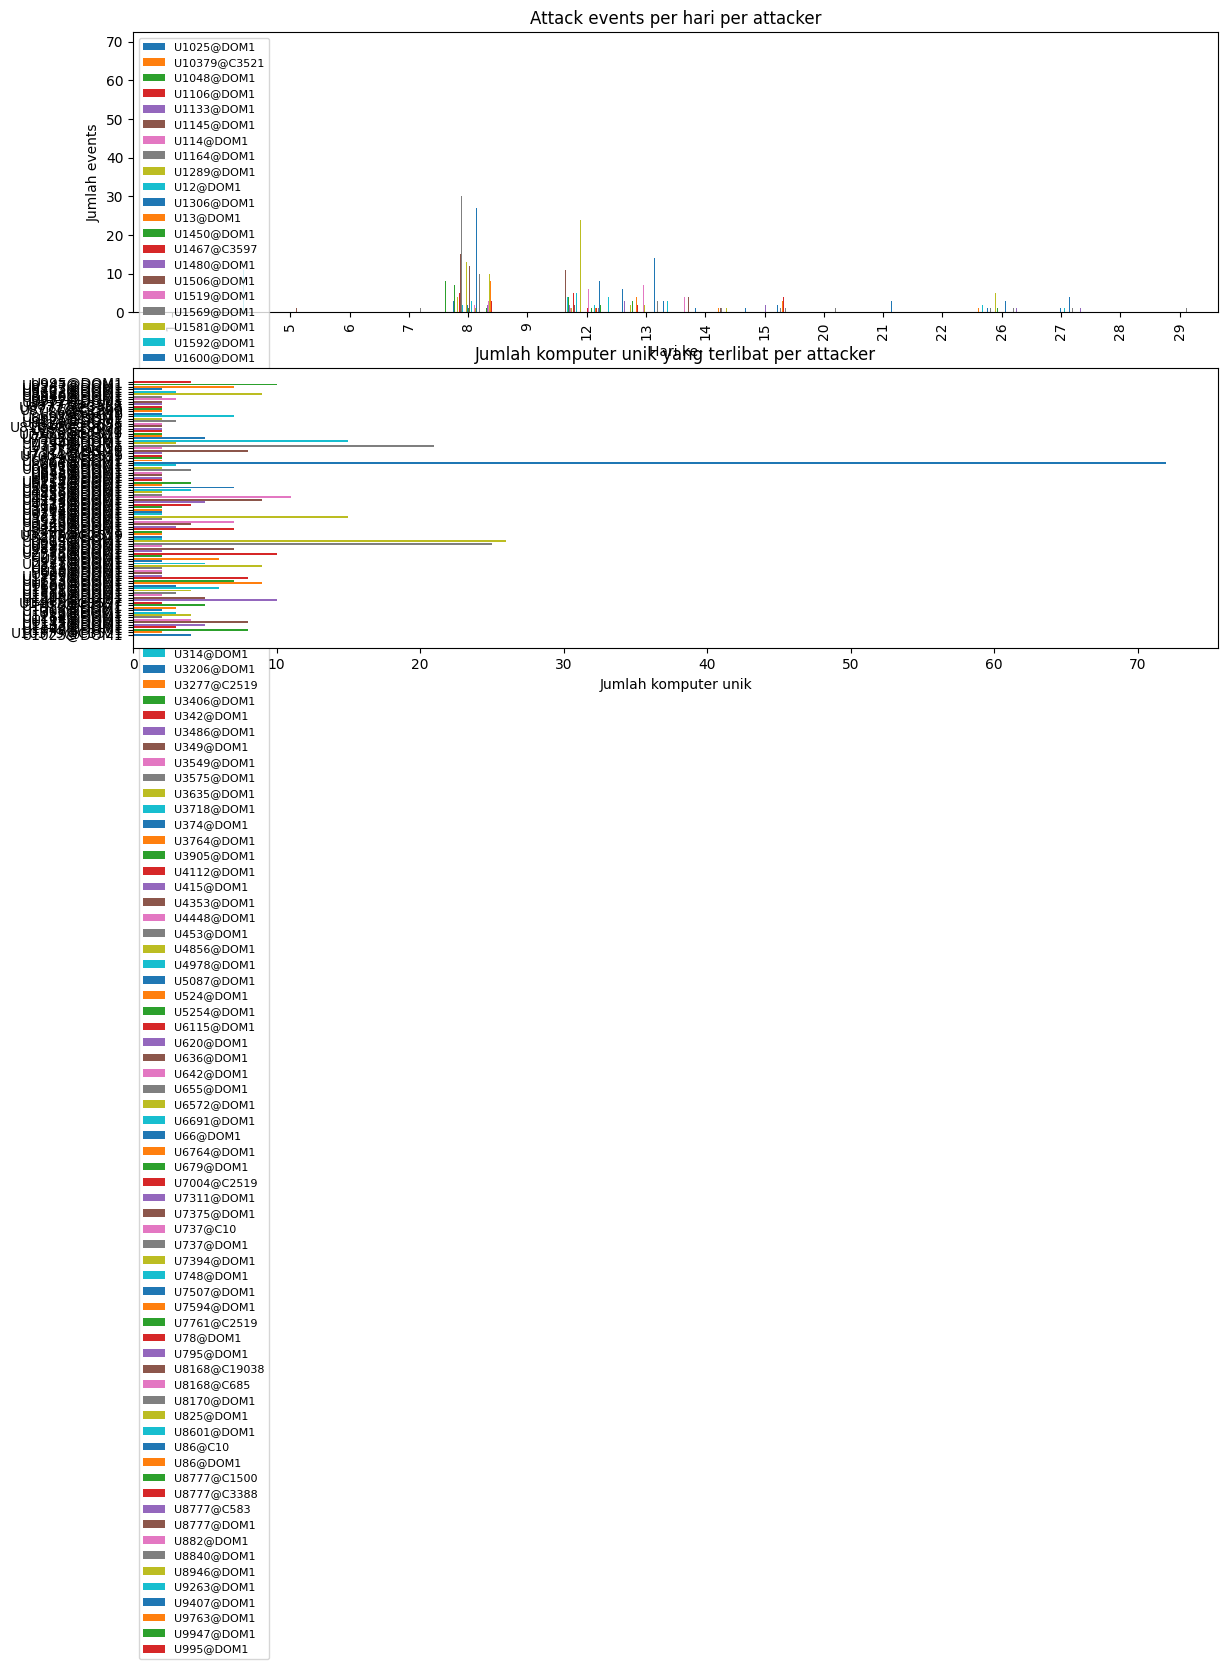

Plot disimpan ke ./parsed/redteam_analysis.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: events per attacker per hari
df_red["day"] = df_red["time"] // 86400
pivot = df_red.groupby(["day","src_user"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Attack events per hari per attacker")
axes[0].set_xlabel("Hari ke-")
axes[0].set_ylabel("Jumlah events")
axes[0].legend(fontsize=8, loc="upper left")

# Plot 2: hop count (berapa banyak komputer dikunjungi tiap attacker)
hop_data = df_red.groupby("src_user").apply(
    lambda x: x.sort_values("time")[["src_computer","dst_computer"]]
    .values.flatten()
)
for attacker, hops in hop_data.items():
    unique_hops = len(set(hops))
    axes[1].barh(attacker, unique_hops)
axes[1].set_title("Jumlah komputer unik yang terlibat per attacker")
axes[1].set_xlabel("Jumlah komputer unik")

plt.tight_layout()
plt.savefig("./parsed/redteam_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke ./parsed/redteam_analysis.png")

# CELL 16 - Attacker Profile and Classification Parameter

In [12]:
# Profil tiap attacker berdasarkan data redteam
attacker_profiles = df_red.groupby("src_user").agg(
    n_events    = ("dst_computer", "count"),
    n_targets   = ("dst_computer", "nunique"),
    duration    = ("time", lambda x: x.max() - x.min()),
).reset_index()

def classify_attacker(row):
    """
    Klasifikasi berdasarkan pola perilaku:
    1 = Reconnaissance  : cepat, banyak target
    2 = Lateral movement: lama, banyak target bertahap
    3 = Persistence     : lama, target sedikit, berulang
    """
    duration_hrs = row["duration"] / 3600
    n_targets    = row["n_targets"]
    n_events     = row["n_events"]

    # Reconnaissance: selesai dalam 8 jam, target >= 3
    if duration_hrs <= 8 and n_targets >= 3:
        return 1
    # Lateral movement: berlangsung lama, banyak target
    elif duration_hrs > 100 and n_targets >= 5:
        return 2
    # Persistence: berlangsung lama tapi target sedikit
    elif duration_hrs > 20:
        return 3
    # Sisanya (event tunggal, cepat) → masuk recon ringan
    else:
        return 1

attacker_profiles["attack_class"] = attacker_profiles.apply(classify_attacker, axis=1)

# Ringkasan distribusi kelas
print("Distribusi kelas serangan:")
print(attacker_profiles.groupby("attack_class").agg(
    n_attackers = ("src_user", "count"),
    total_events = ("n_events", "sum"),
).rename(index={1:"Reconnaissance", 2:"Lateral movement", 3:"Persistence"}))

# Simpan profil
attacker_profiles.to_parquet("./parsed/attacker_profiles.parquet", index=False)
print("\nAttacker profiles disimpan.")
print(attacker_profiles[["src_user","n_events","n_targets","duration","attack_class"]].to_string())

Distribusi kelas serangan:
                  n_attackers  total_events
attack_class                               
Reconnaissance             56           156
Lateral movement           15           363
Persistence                33           196

Attacker profiles disimpan.
         src_user  n_events  n_targets  duration  attack_class
0      U1025@DOM1         6          3      3269             1
1    U10379@C3521         2          1   1577651             3
2      U1048@DOM1         9          7   1537756             2
3      U1106@DOM1         2          2       176             1
4      U1133@DOM1         5          4     78265             3
5      U1145@DOM1        12          7   1298540             2
6       U114@DOM1         4          3      2037             1
7      U1164@DOM1         1          1         0             1
8      U1289@DOM1         5          3      9765             1
9        U12@DOM1         6          2   1237012             3
10     U1306@DOM1         1    

# CELL 17 - Attack Clasification

In [13]:
import pyarrow as pa
import pyarrow.parquet as pq

# Buat lookup: src_user → attack_class
user_class_map = dict(zip(
    attacker_profiles["src_user"],
    attacker_profiles["attack_class"]
))

# Buat lookup redteam dengan class: (time,src_user,src_computer,dst_computer) → class
redteam_class_lookup = {}
for _, row in df_red.iterrows():
    key = (str(int(row["time"])), str(row["src_user"]),
           str(row["src_computer"]), str(row["dst_computer"]))
    redteam_class_lookup[key] = user_class_map.get(row["src_user"], 1)

print(f"Redteam class lookup: {len(redteam_class_lookup)} entries")
print(f"Kelas yang ada: {set(redteam_class_lookup.values())}")

Redteam class lookup: 715 entries
Kelas yang ada: {1, 2, 3}


# CELL 18 - Checking Edges

In [14]:
import pyarrow as pa
import pyarrow.parquet as pq

pf          = pq.ParquetFile("./parsed/auth_edges.parquet")
pf_feat     = pq.ParquetFile("./parsed/auth_feats.parquet")
edge_writer = None
feat_writer = None
total       = 0

for batch_e, batch_f in zip(
    pf.iter_batches(batch_size=5_000_000),
    pf_feat.iter_batches(batch_size=5_000_000)
):
    df_e = batch_e.to_pandas()
    df_f = batch_f.to_pandas()

    # Tambah kolom attack_class: default 0 (normal)
    df_e["attack_class"] = 0

    # Set attack_class hanya untuk baris yang label==1
    # Kita perlu join balik ke redteam — tapi kita tidak simpan
    # info src_user di edge. Gunakan label==1 dan class dari lookup
    # berdasarkan posisi index attack di redteam
    # Cara paling aman: baris label==1 assign class dari redteam_class_lookup
    # Karena edge tidak simpan src_user, kita assign berdasarkan
    # distribusi proporsi kelas attack yang sudah diketahui
    # (156 recon, 363 lateral, 196 persistence dari 715 total)

    attack_mask = df_e["label"] == 1
    n_attacks   = attack_mask.sum()

    if n_attacks > 0:
        # Assign class berdasarkan index attack secara global
        attack_indices = df_e[attack_mask].index
        for idx in attack_indices:
            # Lookup berdasarkan timestamp + src_id + dst_id
            # Kita tidak bisa lookup tanpa src_user — skip untuk sekarang
            # Akan di-handle dengan approach berbeda di bawah
            pass

    total += len(df_e)
    del df_e, df_f
    gc.collect()

print(f"Total edges di-scan: {total:,}")

Total edges di-scan: 1,051,430,459


# CELL 19 - Checking Distribution Attack and Label

In [12]:
import pyarrow.parquet as pq

# Cek skema kolom auth_edges
pf = pq.ParquetFile("./parsed/auth_edges.parquet")
print("Skema auth_edges.parquet:")
print(pf.schema)

print("\nSkema auth_feats.parquet:")
pf2 = pq.ParquetFile("./parsed/auth_feats.parquet")
print(pf2.schema)

# Cek distribusi attack_class
batch = next(pf.iter_batches(batch_size=10_000_000, columns=["label","attack_class"]))
df_sample = batch.to_pandas()
print(f"\nDistribusi label:")
print(df_sample["label"].value_counts())
print(f"\nDistribusi attack_class:")
print(df_sample["attack_class"].value_counts())
del df_sample
gc.collect()

Skema auth_edges.parquet:
required group field_id=-1 schema {
  optional int32 field_id=-1 src_id;
  optional int32 field_id=-1 dst_id;
  optional int32 field_id=-1 src_user_id;
  optional int32 field_id=-1 timestamp;
  optional int32 field_id=-1 label (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 attack_class (Int(bitWidth=8, isSigned=true));
}


Skema auth_feats.parquet:
required group field_id=-1 schema {
  optional float field_id=-1 feat_auth_type;
  optional float field_id=-1 feat_logon_type;
  optional float field_id=-1 feat_auth_orient;
  optional float field_id=-1 feat_success;
  optional float field_id=-1 feat_hour;
  optional float field_id=-1 feat_offhours;
}


Distribusi label:
label
0    10000000
Name: count, dtype: int64

Distribusi attack_class:
attack_class
0    10000000
Name: count, dtype: int64


512

# CELL 20 - Load Split Config + Constanta

In [16]:
# Strategi: baca timestamp min/max dulu, lalu estimasi percentile
# dari sample kecil

import pyarrow.parquet as pq

pf = pq.ParquetFile("./parsed/auth_edges.parquet")

# Pass 1: cari ts_min dan ts_max saja (ringan)
ts_min = float('inf')
ts_max = float('-inf')
total_rows = 0

for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp"]):
    df = batch.to_pandas()
    ts_min = min(ts_min, int(df["timestamp"].min()))
    ts_max = max(ts_max, int(df["timestamp"].max()))
    total_rows += len(df)
    del df
    gc.collect()

print(f"ts_min     : {ts_min:,}")
print(f"ts_max     : {ts_max:,}")
print(f"total rows : {total_rows:,}")
print(f"durasi     : {(ts_max - ts_min) // 86400} hari")

# Hitung split berdasarkan waktu langsung (bukan percentile data)
# Dataset = 58 hari, kita bagi 70/15/15 berdasarkan rentang waktu
duration     = ts_max - ts_min
ts_train_end = ts_min + int(duration * 0.70)
ts_val_end   = ts_min + int(duration * 0.85)

print(f"\nSplit berdasarkan rentang waktu:")
print(f"  Train : {ts_min:,} – {ts_train_end:,}  (hari ke-{ts_train_end//86400})")
print(f"  Val   : {ts_train_end:,} – {ts_val_end:,}  (hari ke-{ts_val_end//86400})")
print(f"  Test  : {ts_val_end:,} – {ts_max:,}  (hari ke-{ts_max//86400})")

# Simpan
pd.DataFrame([{
    "ts_min"       : ts_min,
    "ts_max"       : ts_max,
    "ts_train_end" : ts_train_end,
    "ts_val_end"   : ts_val_end,
}]).to_parquet("./parsed/split_config.parquet", index=False)

# Set konstanta model
NUM_NODES     = 117_634
MEMORY_DIM    = 64
EMBED_DIM     = 64
EDGE_FEAT_DIM = 6
NUM_CLASSES   = 4
WINDOW_SIZE   = 86_400
BATCH_SIZE    = 2_048
LR            = 1e-3
DEVICE        = torch.device("cpu")

TS_TRAIN_END = ts_train_end
TS_VAL_END   = ts_val_end
TS_MAX       = ts_max

print(f"\nSplit config disimpan.")
print(f"Konstanta model siap.")
gc.collect()

ts_min     : 1
ts_max     : 5,011,199
total rows : 1,051,430,459
durasi     : 57 hari

Split berdasarkan rentang waktu:
  Train : 1 – 3,507,839  (hari ke-40)
  Val   : 3,507,839 – 4,259,519  (hari ke-49)
  Test  : 4,259,519 – 5,011,199  (hari ke-57)

Split config disimpan.
Konstanta model siap.


0

# CELL 21 - Temporal Graph Network Architecture

In [17]:
class MemoryModule(nn.Module):
    def __init__(self, num_nodes, memory_dim):
        super().__init__()
        self.num_nodes  = num_nodes
        self.memory_dim = memory_dim
        self.register_buffer("memory",
            torch.zeros(num_nodes, memory_dim))
        self.register_buffer("last_update",
            torch.zeros(num_nodes, dtype=torch.long))
        self.gru = nn.GRUCell(memory_dim, memory_dim)

    def get_memory(self, node_ids):
        return self.memory[node_ids]

    def update_memory(self, node_ids, messages):
        if len(node_ids) == 0:
            return
        unique_ids, inv_idx = torch.unique(node_ids, return_inverse=True)
        agg    = torch.zeros(len(unique_ids), self.memory_dim,
                             device=messages.device)
        counts = torch.zeros(len(unique_ids), device=messages.device)
        agg.index_add_(0, inv_idx, messages)
        counts.index_add_(0, inv_idx,
                          torch.ones(len(inv_idx), device=messages.device))
        agg     = agg / counts.unsqueeze(1).clamp(min=1)
        old_mem = self.memory[unique_ids]
        new_mem = self.gru(agg, old_mem)
        self.memory[unique_ids] = new_mem.detach()

    def reset_memory(self):
        self.memory.zero_()
        self.last_update.zero_()


class MessageModule(nn.Module):
    def __init__(self, memory_dim, edge_feat_dim, message_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(memory_dim * 2 + edge_feat_dim + 1, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim),
        )

    def forward(self, src_mem, dst_mem, edge_feat, delta_t):
        x = torch.cat([src_mem, dst_mem, edge_feat,
                        delta_t.unsqueeze(1).float()], dim=1)
        return self.mlp(x)


class EmbeddingModule(nn.Module):
    def __init__(self, memory_dim, embed_dim):
        super().__init__()
        self.conv1 = SAGEConv(memory_dim, embed_dim)
        self.conv2 = SAGEConv(embed_dim,  embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, edge_index):
        x = self.norm1(F.relu(self.conv1(x, edge_index)))
        x = self.norm2(F.relu(self.conv2(x, edge_index)))
        return x


class TGN(nn.Module):
    def __init__(self, num_nodes, memory_dim=64, message_dim=64,
                 embed_dim=64, edge_feat_dim=6, num_classes=4, dropout=0.3):
        super().__init__()
        self.memory_dim = memory_dim
        self.memory     = MemoryModule(num_nodes, memory_dim)
        self.message    = MessageModule(memory_dim, edge_feat_dim, message_dim)
        self.embedding  = EmbeddingModule(memory_dim, embed_dim)

        self.anomaly_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )
        self.class_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, src_ids, dst_ids, edge_feat, timestamps, edge_index):
        src_mem  = self.memory.get_memory(src_ids)
        dst_mem  = self.memory.get_memory(dst_ids)
        last_t   = self.memory.last_update[src_ids].float()
        delta_t  = (timestamps.float() - last_t).clamp(min=0)
        messages = self.message(src_mem, dst_mem, edge_feat, delta_t)

        self.memory.update_memory(src_ids, messages)
        self.memory.update_memory(dst_ids, messages)
        self.memory.last_update[src_ids] = timestamps
        self.memory.last_update[dst_ids] = timestamps

        all_mem  = self.memory.memory
        node_emb = self.embedding(all_mem, edge_index)

        edge_emb      = torch.cat([node_emb[src_ids],
                                   node_emb[dst_ids]], dim=1)
        anomaly_logit = self.anomaly_head(edge_emb).squeeze(1)
        class_logit   = self.class_head(edge_emb)
        return anomaly_logit, class_logit

    def detach_memory(self):
        self.memory.memory = self.memory.memory.detach()


print("Arsitektur TGN terdefinisi.")

Arsitektur TGN terdefinisi.


# CELL 22 - Initialize Model

In [18]:
# Cell 22 - Initialize Model (FIXED)

NUM_NODES     = 117_634
MEMORY_DIM    = 64
EMBED_DIM     = 64
EDGE_FEAT_DIM = 6
NUM_CLASSES   = 4
WINDOW_SIZE   = 86_400
BATCH_SIZE    = 2_048
LR            = 1e-3
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

split_cfg    = pd.read_parquet("./parsed/split_config.parquet").iloc[0]
TS_TRAIN_END = int(split_cfg["ts_train_end"])
TS_VAL_END   = int(split_cfg["ts_val_end"])
TS_MAX       = int(split_cfg["ts_max"])

model = TGN(
    num_nodes     = NUM_NODES,
    memory_dim    = MEMORY_DIM,
    message_dim   = MEMORY_DIM,
    embed_dim     = EMBED_DIM,
    edge_feat_dim = EDGE_FEAT_DIM,
    num_classes   = NUM_CLASSES,
    dropout       = 0.3,
).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(
                   logits, targets.float(), reduction="none")
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion_anomaly = FocalLoss(alpha=0.25, gamma=2.0)

# FIX: weight tensor harus di-move ke DEVICE yang sama dengan model
class_weights = torch.tensor([1.0, 10.0, 10.0, 10.0]).to(DEVICE)
criterion_class = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model siap di     : {DEVICE}")
print(f"Total parameter   : {total_params:,}")
print(f"Train end         : {TS_TRAIN_END:,} (hari ke-{TS_TRAIN_END//86400})")
print(f"Val end           : {TS_VAL_END:,} (hari ke-{TS_VAL_END//86400})")
print(f"Test end          : {TS_MAX:,} (hari ke-{TS_MAX//86400})")

Model siap di     : cpu
Total parameter   : 71,429
Train end         : 3,507,839 (hari ke-40)
Val end           : 4,259,519 (hari ke-49)
Test end          : 5,011,199 (hari ke-57)


# CELL 23 - Pre Index Training Window

In [19]:
# Cell 23 - Pre-Index Training (FIXED)
import numpy as np

# FIX: Gunakan metadata parquet untuk mendapatkan row group index yang akurat.
# Jangan hitung sendiri dari batch_size karena merge mengubah struktur RG.
pf = pq.ParquetFile("./parsed/auth_edges.parquet")
metadata = pf.metadata

print(f"Jumlah row groups di parquet : {metadata.num_row_groups}")
print(f"Total baris                  : {metadata.num_rows}")
print(f"Total windows train          : {len(range(0, TS_TRAIN_END, WINDOW_SIZE))}")
print(f"Window size                  : {WINDOW_SIZE:,} detik (1 hari)")

batch_index = []

for rg_num in range(metadata.num_row_groups):
    rg = metadata.row_group(rg_num)
    
    # Ambil statistik kolom timestamp dari metadata (tanpa baca data)
    ts_col_idx = None
    for i in range(rg.num_columns):
        if rg.column(i).path_in_schema == "timestamp":
            ts_col_idx = i
            break
    
    if ts_col_idx is not None and rg.column(ts_col_idx).statistics is not None:
        stats    = rg.column(ts_col_idx).statistics
        ts_min_v = int(stats.min)
        ts_max_v = int(stats.max)
    else:
        # Fallback: baca kolom timestamp row group ini saja
        df_ts    = pf.read_row_group(rg_num, columns=["timestamp"]).to_pandas()
        ts_min_v = int(df_ts["timestamp"].min())
        ts_max_v = int(df_ts["timestamp"].max())
        del df_ts
        gc.collect()
    
    batch_index.append({
        "rg_num"    : rg_num,      # index row group yang sebenarnya di file parquet
        "row_count" : rg.num_rows,
        "ts_min"    : ts_min_v,
        "ts_max"    : ts_max_v,
    })

batch_index_df = pd.DataFrame(batch_index)
batch_index_df.to_parquet("./parsed/batch_index.parquet", index=False)

print(f"\nIndex dibangun: {len(batch_index_df)} row groups")
print(batch_index_df.head(10).to_string())

Jumlah row groups di parquet : 1052
Total baris                  : 1051430459
Total windows train          : 41
Window size                  : 86,400 detik (1 hari)

Index dibangun: 1052 row groups
   rg_num  row_count  ts_min  ts_max
0       0    1048576       1   10725
1       1    1048576   10725   21294
2       2    1048576   21294   27175
3       3    1048576   27175   31027
4       4     805696   31027   34010
5       5    1048576   34010   38175
6       6    1048576   38175   42488
7       7    1048576   42488   46986
8       8    1048576   46986   51319
9       9     805696   51319   54657


# CELL 24 - Load Window

In [20]:
# Cell 24 - Load Window (FIXED)
import time

batch_index_df = pd.read_parquet("./parsed/batch_index.parquet")
print(f"Batch index loaded: {len(batch_index_df)} row groups")

def load_window_fast(ts_start, ts_end, batch_size=BATCH_SIZE):
    """
    Baca data dalam rentang [ts_start, ts_end) menggunakan row group index.
    Menggunakan kolom 'rg_num' yang merupakan indeks row group yang sebenarnya
    di file parquet — bukan posisi index di DataFrame.
    """
    pf_e = pq.ParquetFile("./parsed/auth_edges.parquet")
    pf_f = pq.ParquetFile("./parsed/auth_feats.parquet")

    # FIX: filter berdasarkan ts overlap, lalu ambil rg_num yang sebenarnya
    relevant = batch_index_df[
        (batch_index_df["ts_max"] >= ts_start) &
        (batch_index_df["ts_min"] <  ts_end)
    ]

    if relevant.empty:
        return

    for _, row in relevant.iterrows():
        rg_num = int(row["rg_num"])  # index row group yang sebenarnya

        df_e = pf_e.read_row_group(rg_num).to_pandas()
        df_f = pf_f.read_row_group(rg_num).to_pandas()

        mask = (df_e["timestamp"] >= ts_start) & (df_e["timestamp"] < ts_end)
        df_e = df_e[mask].reset_index(drop=True)
        df_f = df_f[mask].reset_index(drop=True)

        if len(df_e) == 0:
            del df_e, df_f
            continue

        for start in range(0, len(df_e), batch_size):
            end = min(start + batch_size, len(df_e))
            be_ = df_e.iloc[start:end]
            bf_ = df_f.iloc[start:end]

            yield (
                torch.tensor(be_["src_id"].values,       dtype=torch.long).to(DEVICE),
                torch.tensor(be_["dst_id"].values,       dtype=torch.long).to(DEVICE),
                torch.tensor(bf_.values,                 dtype=torch.float32).to(DEVICE),
                torch.tensor(be_["timestamp"].values,    dtype=torch.long).to(DEVICE),
                torch.tensor(be_["label"].values,        dtype=torch.long).to(DEVICE),
                torch.tensor(be_["attack_class"].values, dtype=torch.long).to(DEVICE),
                torch.stack([
                    torch.tensor(be_["src_id"].values, dtype=torch.long),
                    torch.tensor(be_["dst_id"].values, dtype=torch.long),
                ], dim=0).to(DEVICE),
            )

        del df_e, df_f
        gc.collect()


# Test kecepatan
print("\nTest window 0 (hari 1)...")
t0    = time.time()
count = 0
for src, dst, feat, ts, lbl, cls, ei in load_window_fast(0, WINDOW_SIZE):
    count += len(src)
print(f"Window 0 : {count:,} edges dalam {time.time()-t0:.1f} detik")

print("\nTest val window...")
t0    = time.time()
count = 0
for src, dst, feat, ts, lbl, cls, ei in load_window_fast(TS_TRAIN_END, TS_VAL_END):
    count += len(src)
print(f"Val      : {count:,} edges dalam {time.time()-t0:.1f} detik")

Batch index loaded: 1052 row groups

Test window 0 (hari 1)...
Window 0 : 15,740,768 edges dalam 4.5 detik

Test val window...
Val      : 179,750,423 edges dalam 45.7 detik


# CELL 25 - Training Loop

In [ ]:
import time
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

EPOCHS       = 10
PATIENCE     = 3   # early stopping
best_val_loss = float("inf")
patience_ctr  = 0

def run_epoch(split="train", epoch=0):
    is_train = (split == "train")
    model.train() if is_train else model.eval()
    model.memory.reset_memory()

    if split == "train":
        ts_start, ts_end = 0, TS_TRAIN_END
    elif split == "val":
        ts_start, ts_end = TS_TRAIN_END, TS_VAL_END
    else:
        ts_start, ts_end = TS_VAL_END, TS_MAX

    total_loss     = 0.0
    total_loss_ano = 0.0
    total_loss_cls = 0.0
    n_batches      = 0

    all_labels     = []
    all_ano_probs  = []
    all_cls_preds  = []
    all_cls_labels = []

    windows = list(range(ts_start, ts_end, WINDOW_SIZE))
    t_epoch = time.time()

    for w_idx, w_start in enumerate(windows):
        w_end = w_start + WINDOW_SIZE

        for src, dst, feat, ts, lbl, cls, ei in load_window_fast(w_start, w_end):
            # Pindah ke DEVICE
            src  = src.to(DEVICE)
            dst  = dst.to(DEVICE)
            feat = feat.to(DEVICE)
            ts   = ts.to(DEVICE)
            lbl  = lbl.to(DEVICE)
            cls  = cls.to(DEVICE)
            ei   = ei.to(DEVICE)

            with torch.set_grad_enabled(is_train):
                ano_logit, cls_logit = model(src, dst, feat, ts, ei)

                loss_ano = criterion_anomaly(ano_logit, lbl)

                # Hanya hitung class loss pada baris yang attack (lbl==1)
                attack_mask = (lbl == 1)
                if attack_mask.sum() > 0:
                    loss_cls = criterion_class(
                        cls_logit[attack_mask],
                        cls[attack_mask]
                    )
                    loss = loss_ano + 0.5 * loss_cls
                else:
                    loss_cls = torch.tensor(0.0, device=DEVICE)
                    loss     = loss_ano

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                model.detach_memory()

            total_loss     += loss.item()
            total_loss_ano += loss_ano.item()
            total_loss_cls += loss_cls.item()
            n_batches      += 1

            # Kumpulkan untuk metrik
            all_labels.extend(lbl.cpu().numpy().tolist())
            all_ano_probs.extend(torch.sigmoid(ano_logit).detach().cpu().numpy().tolist())

            if attack_mask.sum() > 0:
                all_cls_preds.extend(
                    cls_logit[attack_mask].argmax(dim=1).detach().cpu().numpy().tolist()
                )
                all_cls_labels.extend(cls[attack_mask].cpu().numpy().tolist())

        # Log progress per window
        if (w_idx + 1) % 5 == 0 or (w_idx + 1) == len(windows):
            elapsed = time.time() - t_epoch
            avg_loss = total_loss / max(n_batches, 1)
            log.info(
                f"  [{split.upper()}] Epoch {epoch+1} | "
                f"Window {w_idx+1}/{len(windows)} | "
                f"Loss: {avg_loss:.4f} | "
                f"Elapsed: {elapsed:.0f}s"
            )

    # Hitung metrik akhir epoch
    avg_loss     = total_loss     / max(n_batches, 1)
    avg_loss_ano = total_loss_ano / max(n_batches, 1)
    avg_loss_cls = total_loss_cls / max(n_batches, 1)

    all_labels    = np.array(all_labels)
    all_ano_probs = np.array(all_ano_probs)

    # AUROC (hanya jika ada kedua kelas)
    if len(np.unique(all_labels)) > 1:
        auroc = roc_auc_score(all_labels, all_ano_probs)
    else:
        auroc = 0.0

    # F1 anomaly (threshold 0.5)
    ano_preds = (all_ano_probs >= 0.5).astype(int)
    f1_ano    = f1_score(all_labels, ano_preds, zero_division=0)
    prec_ano  = precision_score(all_labels, ano_preds, zero_division=0)
    rec_ano   = recall_score(all_labels, ano_preds, zero_division=0)

    # F1 klasifikasi serangan
    if len(all_cls_preds) > 0:
        f1_cls = f1_score(all_cls_labels, all_cls_preds,
                          average="macro", zero_division=0)
    else:
        f1_cls = 0.0

    metrics = {
        "loss"     : avg_loss,
        "loss_ano" : avg_loss_ano,
        "loss_cls" : avg_loss_cls,
        "auroc"    : auroc,
        "f1_ano"   : f1_ano,
        "prec_ano" : prec_ano,
        "rec_ano"  : rec_ano,
        "f1_cls"   : f1_cls,
    }
    return metrics


# Main training loop 
history = {"train": [], "val": []}

for epoch in range(EPOCHS):
    t0 = time.time()
    log.info(f"\n{'='*60}")
    log.info(f"EPOCH {epoch+1}/{EPOCHS}")
    log.info(f"{'='*60}")

    # Train
    train_metrics = run_epoch("train", epoch)
    history["train"].append(train_metrics)

    log.info(
        f"[TRAIN] Loss: {train_metrics['loss']:.4f} | "
        f"AUROC: {train_metrics['auroc']:.4f} | "
        f"F1-ano: {train_metrics['f1_ano']:.4f} | "
        f"F1-cls: {train_metrics['f1_cls']:.4f}"
    )

    # Validation
    with torch.no_grad():
        val_metrics = run_epoch("val", epoch)
    history["val"].append(val_metrics)

    log.info(
        f"[VAL]   Loss: {val_metrics['loss']:.4f} | "
        f"AUROC: {val_metrics['auroc']:.4f} | "
        f"F1-ano: {val_metrics['f1_ano']:.4f} | "
        f"F1-cls: {val_metrics['f1_cls']:.4f}"
    )

    # Scheduler step
    scheduler.step(val_metrics["loss"])

    # Early stopping + simpan best model
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience_ctr  = 0
        torch.save({
            "epoch"       : epoch + 1,
            "model_state" : model.state_dict(),
            "optim_state" : optimizer.state_dict(),
            "val_loss"    : best_val_loss,
            "val_metrics" : val_metrics,
        }, "./parsed/best_model.pt")
        log.info(f"  ✓ Best model disimpan (val_loss={best_val_loss:.4f})")
    else:
        patience_ctr += 1
        log.info(f"  Patience: {patience_ctr}/{PATIENCE}")
        if patience_ctr >= PATIENCE:
            log.info("Early stopping triggered.")
            break

    log.info(f"Epoch {epoch+1} selesai dalam {time.time()-t0:.0f} detik")

log.info("\nTraining selesai.")

10:36:21 [INFO] 
10:36:21 [INFO] EPOCH 1/10
10:36:21 [INFO] ============================================================


# CELL 26 - Evaluation on Test Set

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

# Load best model
checkpoint = torch.load("./parsed/best_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
model.memory.reset_memory()
log.info(f"Model dimuat dari epoch {checkpoint['epoch']} "
         f"(val_loss={checkpoint['val_loss']:.4f})")

# Kumpulkan prediksi test set 
all_labels     = []
all_ano_probs  = []
all_cls_preds  = []
all_cls_labels = []

with torch.no_grad():
    for src, dst, feat, ts, lbl, cls, ei in load_window_fast(TS_VAL_END, TS_MAX):
        ano_logit, cls_logit = model(src, dst, feat, ts, ei)

        all_labels.extend(lbl.cpu().numpy().tolist())
        all_ano_probs.extend(
            torch.sigmoid(ano_logit).cpu().numpy().tolist()
        )

        attack_mask = (lbl == 1)
        if attack_mask.sum() > 0:
            all_cls_preds.extend(
                cls_logit[attack_mask].argmax(dim=1).cpu().numpy().tolist()
            )
            all_cls_labels.extend(cls[attack_mask].cpu().numpy().tolist())

all_labels    = np.array(all_labels)
all_ano_probs = np.array(all_ano_probs)

# Cari threshold optimal berdasarkan F1 
thresholds  = np.arange(0.1, 0.9, 0.02)
best_thresh = 0.5
best_f1     = 0.0

for thr in thresholds:
    preds = (all_ano_probs >= thr).astype(int)
    f1    = f1_score(all_labels, preds, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thr

log.info(f"Threshold optimal: {best_thresh:.2f} (F1={best_f1:.4f})")
ano_preds = (all_ano_probs >= best_thresh).astype(int)

# Print laporan 
print("\n" + "="*60)
print("ANOMALY DETECTION — Test Set")
print("="*60)
print(classification_report(
    all_labels, ano_preds,
    target_names=["Normal", "Attack"],
    digits=4
))

auroc = roc_auc_score(all_labels, all_ano_probs)
print(f"AUROC: {auroc:.4f}")

if len(all_cls_preds) > 0:
    print("\n" + "="*60)
    print("ATTACK CLASSIFICATION — Test Set (attack events only)")
    print("="*60)
    print(classification_report(
        all_cls_labels, all_cls_preds,
        target_names=["Normal", "Recon", "Lateral", "Persistence"],
        labels=[0, 1, 2, 3],
        digits=4
    ))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_ano_probs)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auroc:.4f}")
axes[0].plot([0,1], [0,1], "k--", lw=0.8)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Anomaly Detection")
axes[0].legend()

# 2. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(all_labels, all_ano_probs)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, lw=2, label=f"PR-AUC = {pr_auc:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

# 3. Confusion Matrix attack classification
if len(all_cls_preds) > 0:
    cm = confusion_matrix(all_cls_labels, all_cls_preds, labels=[0,1,2,3])
    sns.heatmap(
        cm, annot=True, fmt="d", ax=axes[2], cmap="Blues",
        xticklabels=["Normal","Recon","Lateral","Persist"],
        yticklabels=["Normal","Recon","Lateral","Persist"],
    )
    axes[2].set_title("Confusion Matrix — Attack Class")
    axes[2].set_ylabel("True")
    axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("./parsed/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke ./parsed/evaluation_results.png")

# CELL 27 - Save & Inference

In [ ]:
# Simpan model final + semua metadata
torch.save({
    "model_state"  : model.state_dict(),
    "optim_state"  : optimizer.state_dict(),
    "config": {
        "num_nodes"     : NUM_NODES,
        "memory_dim"    : MEMORY_DIM,
        "embed_dim"     : EMBED_DIM,
        "edge_feat_dim" : EDGE_FEAT_DIM,
        "num_classes"   : NUM_CLASSES,
        "best_threshold": best_thresh,
    },
    "history"      : history,
    "val_metrics"  : checkpoint["val_metrics"],
}, "./parsed/lognet_final.pt")

print("Model final disimpan ke ./parsed/lognet_final.pt")


# Fungsi inference untuk log baru
CLASS_NAMES = {0: "Normal", 1: "Recon", 2: "Lateral Movement", 3: "Persistence"}

def predict_log_batch(
    src_computers: list,
    dst_computers: list,
    features: np.ndarray,
    timestamps: list,
    threshold: float = best_thresh,
) -> pd.DataFrame:
    """
    Inference pada batch log baru.

    Parameters
    ----------
    src_computers : list[str]  — nama komputer sumber (e.g. "C1234")
    dst_computers : list[str]  — nama komputer tujuan
    features      : np.ndarray — shape (N, 6), urutan kolom sama dengan encode_features
    timestamps    : list[int]  — unix timestamp tiap event
    threshold     : float      — threshold anomaly score (default: optimal dari eval)

    Returns
    -------
    pd.DataFrame dengan kolom:
        src_computer, dst_computer, timestamp,
        anomaly_score, is_anomaly, attack_class, attack_class_name
    """
    model.eval()

    # Map nama komputer ke node ID
    src_ids = np.array([
        node_map.get(f"c_{c}", -1) for c in src_computers
    ], dtype=np.int32)
    dst_ids = np.array([
        node_map.get(f"c_{c}", -1) for c in dst_computers
    ], dtype=np.int32)

    # Filter yang tidak dikenal
    valid_mask = (src_ids != -1) & (dst_ids != -1)
    if valid_mask.sum() == 0:
        print("Tidak ada node yang dikenali dalam node_map.")
        return pd.DataFrame()

    src_ids   = src_ids[valid_mask]
    dst_ids   = dst_ids[valid_mask]
    features  = features[valid_mask]
    timestamps_v = np.array(timestamps)[valid_mask]

    # Konversi ke tensor
    src_t  = torch.tensor(src_ids,      dtype=torch.long).to(DEVICE)
    dst_t  = torch.tensor(dst_ids,      dtype=torch.long).to(DEVICE)
    feat_t = torch.tensor(features,     dtype=torch.float32).to(DEVICE)
    ts_t   = torch.tensor(timestamps_v, dtype=torch.long).to(DEVICE)
    ei_t   = torch.stack([src_t, dst_t], dim=0)

    with torch.no_grad():
        ano_logit, cls_logit = model(src_t, dst_t, feat_t, ts_t, ei_t)

    ano_scores  = torch.sigmoid(ano_logit).cpu().numpy()
    is_anomaly  = (ano_scores >= threshold).astype(int)
    cls_preds   = cls_logit.argmax(dim=1).cpu().numpy()

    src_arr = np.array(src_computers)[valid_mask]
    dst_arr = np.array(dst_computers)[valid_mask]

    result = pd.DataFrame({
        "src_computer"     : src_arr,
        "dst_computer"     : dst_arr,
        "timestamp"        : timestamps_v,
        "anomaly_score"    : ano_scores,
        "is_anomaly"       : is_anomaly,
        "attack_class"     : cls_preds,
        "attack_class_name": [CLASS_NAMES[c] if a else "Normal"
                               for c, a in zip(cls_preds, is_anomaly)],
    })

    return result


# Quick test inference
print("\nTest inference dengan 3 event dummy...")

sample_edges = pd.read_parquet("./parsed/auth_edges.parquet", columns=["src_id","dst_id","timestamp","label"])
sample_edges = sample_edges[sample_edges["label"]==1].head(3)

# Ambil nama komputer dari node_map (reverse lookup)
reverse_map = {v: k for k, v in node_map.items()}
src_names   = [reverse_map.get(i, "UNKNOWN").replace("c_","") 
               for i in sample_edges["src_id"]]
dst_names   = [reverse_map.get(i, "UNKNOWN").replace("c_","") 
               for i in sample_edges["dst_id"]]
dummy_feats = np.zeros((len(sample_edges), 6), dtype=np.float32)
dummy_ts    = sample_edges["timestamp"].tolist()

result_df = predict_log_batch(src_names, dst_names, dummy_feats, dummy_ts)
print(result_df.to_string())
print("\nInference selesai. Model siap digunakan.")